In [111]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


In [112]:
data1 = pd.read_csv('/content/loan_approval_dataset.csv')
data1

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [113]:
data1.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [114]:
data1.shape

(4269, 13)

In [115]:
data1.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [116]:
labels = LabelEncoder()
data1[' education'] = labels.fit_transform(data1[' education'])
data1[' self_employed'] = labels.fit_transform(data1[' self_employed'])
data1[' loan_status'] = labels.fit_transform(data1[' loan_status'])

In [117]:
x = data1.drop(columns=[' loan_status'],axis=1)
y = data1[' loan_status']
print(x)
print(y)

      loan_id   no_of_dependents   education   self_employed   income_annum  \
0           1                  2           0               0        9600000   
1           2                  0           1               1        4100000   
2           3                  3           0               0        9100000   
3           4                  3           0               0        8200000   
4           5                  5           1               1        9800000   
...       ...                ...         ...             ...            ...   
4264     4265                  5           0               1        1000000   
4265     4266                  0           1               1        3300000   
4266     4267                  2           1               0        6500000   
4267     4268                  1           1               0        4100000   
4268     4269                  1           0               0        9200000   

       loan_amount   loan_term   cibil_score   resi

In [118]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3415, 12)
(854, 12)
(3415,)
(854,)


In [119]:
model1 = AdaBoostClassifier(n_estimators=90)
model2 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.9, max_depth=1, random_state=50)


In [120]:
model1.fit(x_train,y_train)
model2.fit(x_train,y_train)

GradientBoostingClassifier(learning_rate=0.9, max_depth=1, random_state=50)

In [121]:
y_pred1 = model1.predict(x_test)
y_pred2 = model2.predict(x_test)

In [122]:
accuracy1 = accuracy_score(y_test,y_pred1)
accuracy2 = accuracy_score(y_test,y_pred2)
print(accuracy1)
print(accuracy2)
#

0.9625292740046838
0.9824355971896955


In [123]:
from sklearn.ensemble import RandomForestClassifier
model3 = RandomForestClassifier(n_estimators=100)
model3.fit(x_train,y_train)
y_pred3 = model3.predict(x_test)
accuracy3 = accuracy_score(y_test,y_pred3)
print(accuracy3)

0.9836065573770492


In [124]:
from xgboost import XGBClassifier

In [125]:
model4 = XGBClassifier(
    n_estimator=100,
    max_depth = 6,
    learning_rate=0.6,
    random_state=50,
    gamma = 1.0,
    colsample_bytree=0.8,
    subsample=0.8
    )
model4.fit(x_train,y_train)
y_pred4 = model4.predict(x_test)
accuracy4= accuracy_score(y_test,y_pred4)
print(accuracy3)

0.9836065573770492


In [126]:
from sklearn.ensemble import VotingClassifier
model5 = VotingClassifier(estimators=[('ada',model1),('gb',model2),('rf',model3) , ('xgb' , model4)],voting='hard')
model5.fit(x_train,y_train)

VotingClassifier(estimators=[('ada', AdaBoostClassifier(n_estimators=90)),
                             ('gb',
                              GradientBoostingClassifier(learning_rate=0.9,
                                                         max_depth=1,
                                                         random_state=50)),
                             ('rf', RandomForestClassifier()),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds...
                                            feature_weights=None, gamma=1.0,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.6, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimator=100, n_estimators=None,
                                            n_jobs=None, ...))])

In [127]:
y_pred5 = model5.predict(x_test)
accuracy5 = accuracy_score(y_test,y_pred5)
print(accuracy5)

0.9812646370023419


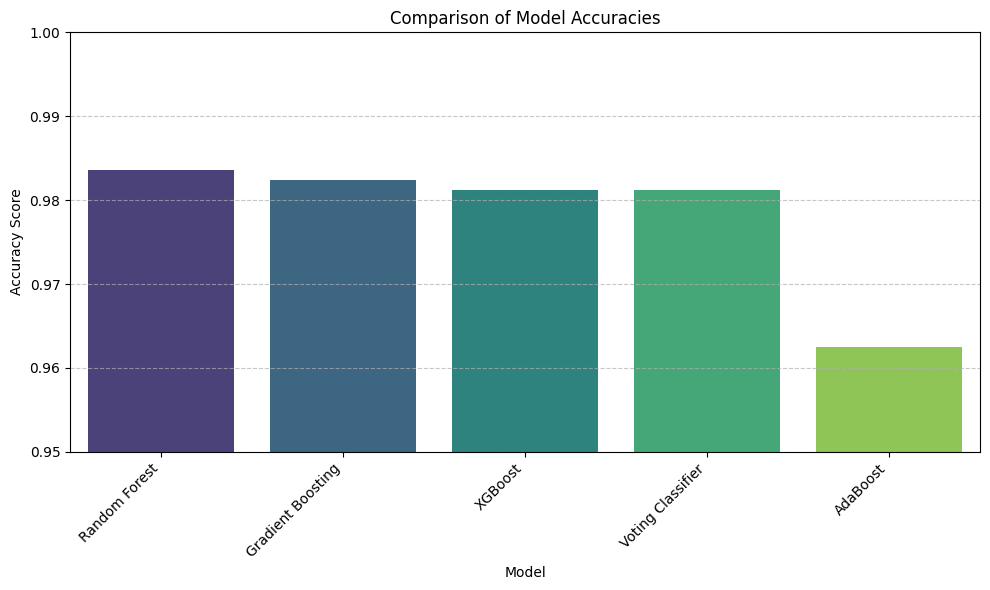

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for model accuracies
model_accuracies = pd.DataFrame({
    'Model': ['AdaBoost', 'Gradient Boosting', 'Random Forest', 'XGBoost', 'Voting Classifier'],
    'Accuracy': [accuracy1, accuracy2, accuracy3, accuracy4, accuracy5]
})

# Sort by accuracy for better visualization
model_accuracies = model_accuracies.sort_values(by='Accuracy', ascending=False)

# Create the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy Score')
plt.ylim(0.95, 1.0) # Set y-axis limit to highlight differences
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()